# Novo Nordisk - Revenue & Segment Trend Analysis

Data source: Novo Nordisk Annual Reports (20-F filings) and public financial data, 2015-2025.

Before running: upload `1_revenue_trends.csv` using the folder icon on the left sidebar.

In [ ]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

## 1. Load data and create a SQL database

In [ ]:
df = pd.read_csv("1_revenue_trends.csv")
conn = sqlite3.connect(":memory:")
df.to_sql("revenue_data", conn, index=False, if_exists="replace")
df.head()

,metric,period,value,unit,source
0,annual_total_revenue,2015,16060,USD_million,MacroTrends/company filings
1,annual_total_revenue,2016,16611,USD_million,MacroTrends/company filings
2,annual_total_revenue,2017,16967,USD_million,MacroTrends/company filings
3,annual_total_revenue,2018,17099,USD_million,MacroTrends/company filings
4,annual_total_revenue,2019,18291,USD_million,MacroTrends/company filings


## 2. Annual revenue trend

In [ ]:
annual = pd.read_sql("""
    SELECT period AS year, value AS revenue_usd_million
    FROM revenue_data
    WHERE metric = 'annual_total_revenue'
    ORDER BY year
""", conn)
annual

,year,revenue_usd_million
0,2015,16060
1,2016,16611
2,2017,16967
3,2018,17099
4,2019,18291
5,2020,19448
6,2021,22401
7,2022,25057
8,2023,33724
9,2024,42108


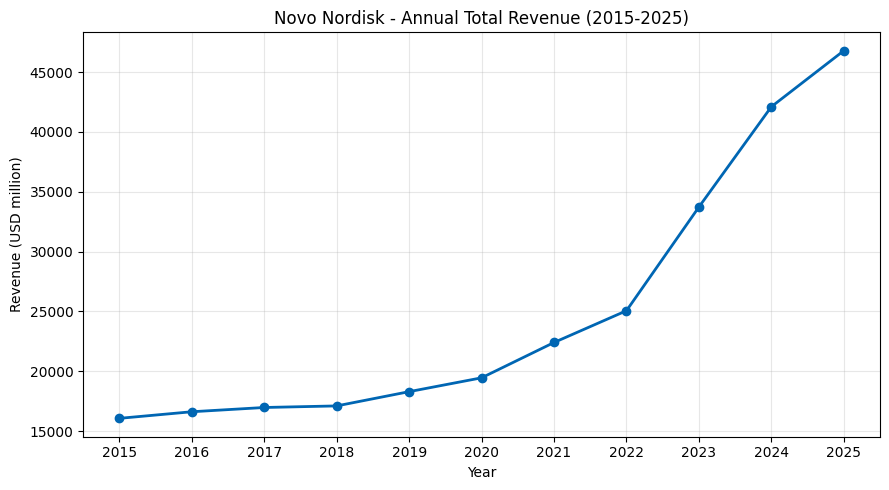

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(annual["year"], annual["revenue_usd_million"], marker="o", linewidth=2, color="#0066B3")
plt.title("Novo Nordisk - Annual Total Revenue (2015-2025)")
plt.xlabel("Year")
plt.ylabel("Revenue (USD million)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Year-over-year growth rate

In [ ]:
yoy = pd.read_sql("""
    SELECT
        year,
        revenue_usd_million,
        ROUND(
            (revenue_usd_million - LAG(revenue_usd_million) OVER (ORDER BY year))
            * 100.0 / LAG(revenue_usd_million) OVER (ORDER BY year), 1
        ) AS yoy_growth_pct
    FROM (
        SELECT period AS year, value AS revenue_usd_million
        FROM revenue_data
        WHERE metric = 'annual_total_revenue'
    )
    ORDER BY year
""", conn)
yoy

,year,revenue_usd_million,yoy_growth_pct
0,2015,16060,NaN
1,2016,16611,3.4
2,2017,16967,2.1
3,2018,17099,0.8
4,2019,18291,7.0
5,2020,19448,6.3
6,2021,22401,15.2
7,2022,25057,11.9
8,2023,33724,34.6
9,2024,42108,24.9


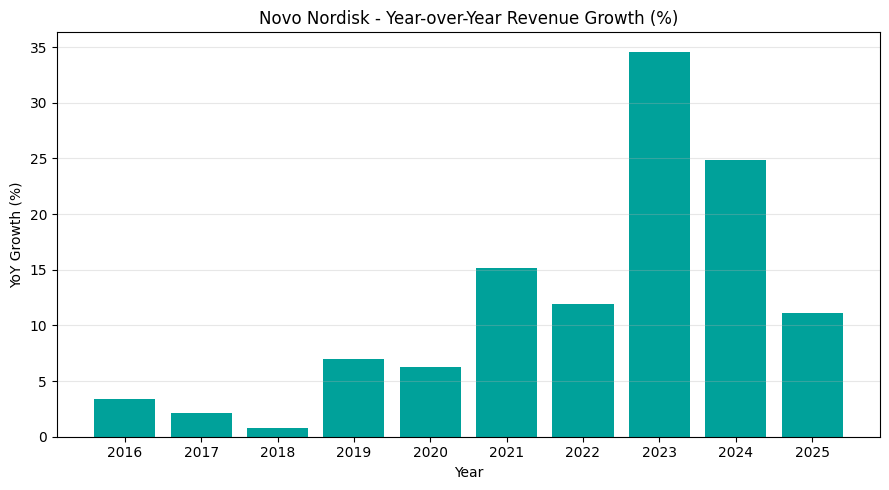

In [ ]:
plt.figure(figsize=(9, 5))
plt.bar(yoy["year"][1:], yoy["yoy_growth_pct"][1:], color="#00A19A")
plt.title("Novo Nordisk - Year-over-Year Revenue Growth (%)")
plt.xlabel("Year")
plt.ylabel("YoY Growth (%)")
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 4. Revenue by business segment

In [ ]:
segment = pd.read_sql("""
    SELECT
        period AS year,
        SUM(CASE WHEN metric = 'segment_revenue_diabetes_obesity' THEN value END) AS diabetes_obesity_dkk_m,
        SUM(CASE WHEN metric = 'segment_revenue_rare_disease' THEN value END) AS rare_disease_dkk_m
    FROM revenue_data
    WHERE metric IN ('segment_revenue_diabetes_obesity', 'segment_revenue_rare_disease')
    GROUP BY period
    ORDER BY year
""", conn)

segment["diabetes_share_pct"] = (
    segment["diabetes_obesity_dkk_m"]
    / (segment["diabetes_obesity_dkk_m"] + segment["rare_disease_dkk_m"])
    * 100
).round(1)
segment

,year,diabetes_obesity_dkk_m,rare_disease_dkk_m,diabetes_share_pct
0,2019,102840,19181,84.3
1,2020,108020,18926,85.1
2,2021,121597,19203,86.4
3,2022,156412,20542,88.4
4,2023,215098,17163,92.6
5,2024,271764,18639,93.6


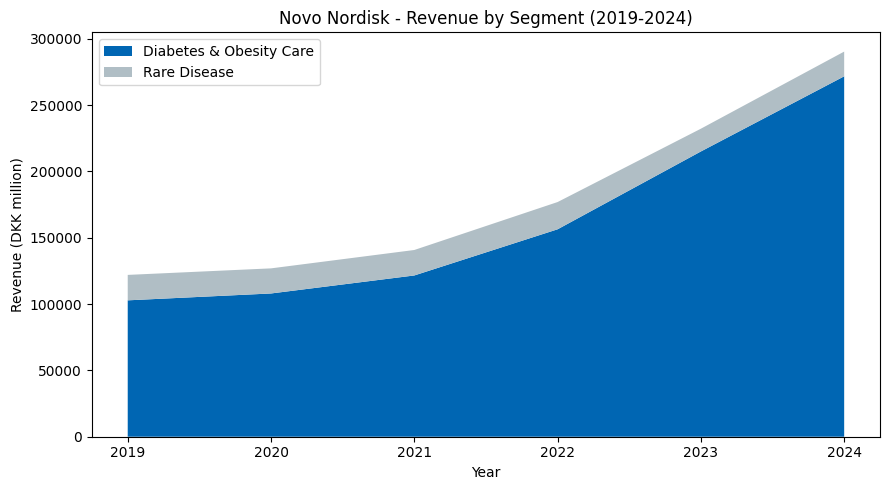

In [ ]:
plt.figure(figsize=(9, 5))
plt.stackplot(
    segment["year"],
    segment["diabetes_obesity_dkk_m"],
    segment["rare_disease_dkk_m"],
    labels=["Diabetes & Obesity Care", "Rare Disease"],
    colors=["#0066B3", "#B0BEC5"]
)
plt.title("Novo Nordisk - Revenue by Segment (2019-2024)")
plt.xlabel("Year")
plt.ylabel("Revenue (DKK million)")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 5. Quarterly revenue trend

In [ ]:
quarterly = pd.read_sql("""
    SELECT period AS quarter, value AS revenue_usd_million
    FROM revenue_data
    WHERE metric = 'quarterly_total_revenue'
    ORDER BY quarter
""", conn)
quarterly

,quarter,revenue_usd_million
0,2023-Q1,7690
1,2023-Q2,7933
2,2023-Q3,8575
3,2023-Q4,9526
4,2024-Q1,9515
5,2024-Q2,9821
6,2024-Q3,10511
7,2024-Q4,12261
8,2025-Q1,11018
9,2025-Q2,11690


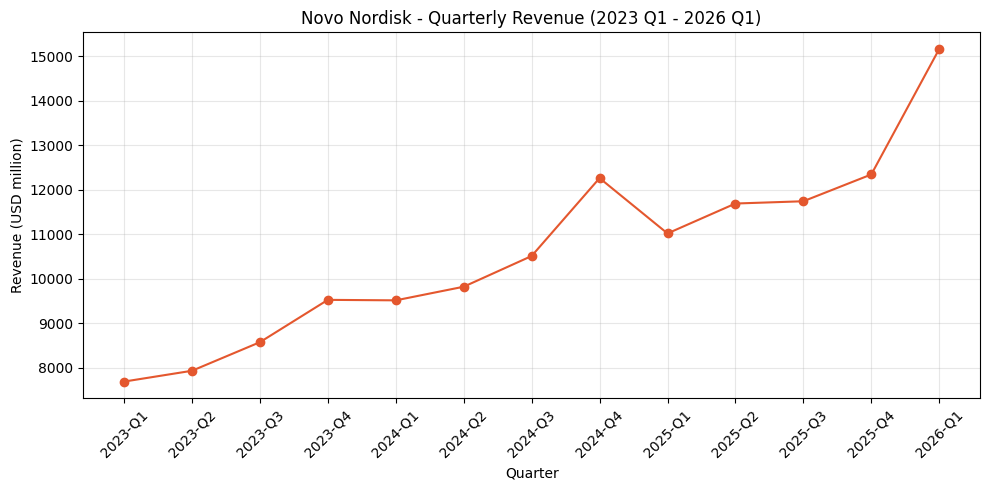

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(quarterly["quarter"], quarterly["revenue_usd_million"], marker="o", color="#E4572E")
plt.title("Novo Nordisk - Quarterly Revenue (2023 Q1 - 2026 Q1)")
plt.xlabel("Quarter")
plt.ylabel("Revenue (USD million)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Key findings

- Total revenue grew from ~$16.1B (2015) to ~$46.8B (2025), roughly a 3x increase.
- Growth accelerated sharply from 2022 onward, peaking at 34.6% YoY in 2023.
- Diabetes & Obesity Care's share of segment revenue rose from 84.3% (2019) to 93.6% (2024), showing increasing concentration in that segment.
- Quarterly data shows a consistent upward trend with no signs of slowdown through Q1 2026.